# Imports

In [66]:
from langchain_groq import ChatGroq # for LLM
from langchain_huggingface.embeddings import HuggingFaceEmbeddings # for embeddings model
from langchain.tools import tool # for custome tools
from langchain_community.document_loaders.csv_loader import CSVLoader # for loading csv file
from langchain_text_splitters import RecursiveCharacterTextSplitter # for chunking data
from langchain_core.messages import SystemMessage, BaseMessage, HumanMessage, AIMessage # for messaging type
from langgraph.graph.message import add_messages # for message adding
from langchain_tavily import TavilySearch # for web search
from pydantic import BaseModel, Field # for structured output
from langgraph.checkpoint.memory import InMemorySaver # for configuration
from mem0 import MemoryClient # for long term memory
import os # for qdrant db connection
# for vector db
from qdrant_client import QdrantClient
from langchain_qdrant import QdrantVectorStore
# for langgraph workflow
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, List, Literal
# env
from dotenv import load_dotenv
load_dotenv("../.env")

True

# Model

In [67]:
llm = ChatGroq(model="moonshotai/kimi-k2-instruct-0905")
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
mem0 = MemoryClient()

In [68]:
class GreetingClassification(BaseModel):
    category: Literal["greeting", "non_greeting"] = Field(
        description="Whether the message is a greeting or non-greeting"
    )

In [69]:
class MemoryClassifcation(BaseModel):
    category: Literal["self_memory", "general_knowledge"] = Field(
        description="Whether the message is a memory base question or knowledge base question"
    )

In [70]:
class AnswerSatisfactionClassification(BaseModel):
    category: Literal["yes", "no"] = Field(
        description="Whether the message is yes or no"
    )

In [71]:
structured_llm = llm.with_structured_output(GreetingClassification, method="json_mode")
structured_llm_answer = llm.with_structured_output(AnswerSatisfactionClassification, method="json_mode")
structured_llm_memory = llm.with_structured_output(MemoryClassifcation, method="json_mode")

In [72]:
def get_rag_docs():
    # loading
    all_docs = []
    for csv_path in ["../datasets/data_preprocessed/device_manuals.csv", "../datasets/data_preprocessed//question_answer.csv"]:
        if os.path.exists(csv_path):
            loader = CSVLoader(file_path=csv_path, encoding="latin1")
            docs = loader.load()  # Each row = 1 Document
            all_docs.extend(docs)  # Keep Document objects
    # chuncking
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1500, chunk_overlap=200)
    texts = text_splitter.split_documents(all_docs)
    
    return texts


In [73]:
COLLECTION_NAME = "project"
vector_db = None

qdrant_client = QdrantClient(
    url=os.getenv("QDRANT_DB_URL"), 
    api_key=os.getenv("QDRANT_API_KEY")
)

collections = [c.name for c in qdrant_client.get_collections().collections]
collections

['project']

In [74]:
if COLLECTION_NAME not in collections: # collection doesnot exists
    print("Collection does not exists: creating collection -> inserting vectors")

    docs = get_rag_docs()

    vector_db = QdrantVectorStore.from_documents(
        docs,
        embeddings,
        url=os.getenv("QDRANT_DB_URL"),
        api_key=os.getenv("QDRANT_API_KEY"),
        prefer_grpc=True,
        collection_name="project",
    )
else: # collection exists
    points = qdrant_client.count("project").count

    if points == 0: # collection exists but vectors does not exist in the collection.
        print("Collection is empty -> inserting vectors in colelction")

        docs = get_rag_docs()
        
        vector_db = QdrantVectorStore.from_documents(
            docs,
            embeddings,
            url=os.getenv("QDRANT_DB_URL"),
            api_key=os.getenv("QDRANT_API_KEY"),
            collection_name=COLLECTION_NAME
        )
    else: # collection and vectors both exists.
        print("Both collection and vectors exists")
        vector_db = QdrantVectorStore(
            client=qdrant_client,
            collection_name="project",  # Your collection name
            embedding=embeddings
        )

Both collection and vectors exists


# Tools

vector search tool

In [75]:
@tool("vector_search", description="Search the device manuals and question answer database for relevant documents.")
def vector_search(query: str):
    """Retrieves top 5 results from FAISS for a given query."""
    try:
        retriever = vector_db.as_retriever(search_type='similarity', search_kwargs={'k': 5})
        result = retriever.invoke(query)
        context = "\n\n".join([doc.page_content for doc in result])
        print("CONTEXT:", context)
        return context
    except Exception as e:
        return f"Vector search Error: {str(e)}"

tavily search tool

In [76]:
tavily_search_tool = TavilySearch(max_results=5,topic="general")

@tool("website_search", description="search on web using tavily search for the latest information.")
def website_search(query):
    """Up-to-date web info via Tavily"""
    try:
        result = tavily_search_tool.invoke({"query": query})

        # Extract and format the results from Tavily response
        if isinstance(result, dict) and 'results' in result:
            formatted_results = []
            for item in result['results']:
                title = item.get('title', 'No title')
                content = item.get('content', 'No content')
                url = item.get('url', '')
                formatted_results.append(f"Title: {title}\nContent: {content}\nURL: {url}")

            return "\n\n".join(formatted_results) if formatted_results else "No results found"
        else:
            return str(result)
    except Exception as e:
        return f"WEB_ERROR::{e}"

# Lang graph state

In [77]:
class ChatState(TypedDict):
    question: str # question from the user
    messages: Annotated[List[BaseMessage], add_messages] # all messages history fot short term memory.
    phase: str # current phase of the chat web or rag
    rag_context: str # context from the rag
    web_context: str # context from the web
    ltm_context: str # context from long term memory

Long Term Memory MEM0 id.

In [78]:
memo_id = "naji"

# Nodes

planning node (Tells the agent what the execution workflow will be)

In [79]:
def planning(state: ChatState):
   print("Planning node started")

   fixed_spelling = llm.invoke(f"Fix the spelling, syntax and any other grammatical errors in the question and just give question donot give aything else: {state['question']}.").content
   print(fixed_spelling)
   SYSTEM_PROMPT = """
      You are an Agentic RAG assistant.

      You MUST follow these rules exactly:

         1. If the question is of greeting category then just go to the fallback LLM node to formally reply.
         2. If the question can be asnwered from long term memory then use fall back llm node to formally reply.
         3. Use vector surch node for each and every question.
         4. If the question is not found in the vector store, use web search node.
         5. If the question is not found in the web search, use fall back llm node.
   
      """

   system = SystemMessage(
      content=SYSTEM_PROMPT  
   )
   user = HumanMessage(content=fixed_spelling)

   greeting_classification_prompt = f"""
      Return a JSON object with a single key 'category' that is either 'greeting' or 'non_greeting'. Don't answer the question 
      Analyze if this message is a greeting: {fixed_spelling}
   """
   classification = structured_llm.invoke(greeting_classification_prompt).category
   print(f"Classification: {classification}")


   memory_classification_prompt = f"""
      Classify the user query into one of these:
         - self_memory: if the user is asking about themselves, their history, projects, identity, or past conversations.
         - general_knowledge: if the question is about people, places, facts, or anything external.

      Return a JSON object with a single key 'category' that is either 'self_memory' or 'general_knowledge'. Don't answer the question.

      Query: {fixed_spelling}
      """
   memory_classification = structured_llm_memory.invoke(memory_classification_prompt).category
   print(f"Memory classification: {memory_classification}")


   # retreiving long term memory.

   memories = mem0.search(state["question"], filters={"user_id": memo_id})

   # Handle dict response format
   memory_list = memories['results']
   context = "Relevant information from previous conversations:\n"
        
   if len(memory_list) == 0:
      context = "No memory context for similar query found."
   else:
      for memory in memory_list:
         context += f"- {memory['memory']}\n"

   print("CONTEXT FROM LONG TERM MEMORY")
   print(context)

   print("Planning node finised")
   if classification.strip().upper() == "GREETING" or memory_classification.strip().upper() == "SELF_MEMORY":
      return {
         "messages": state["messages"] + [system, user],
         "question": fixed_spelling,
         "phase": "fall_back_llm",
         "ltm_context": context
      }
   else:
      return {
         "messages": state["messages"] + [system, user],
         "question": fixed_spelling,
         "phase": "rag",
         "ltm_context": context
      }

context search node (this node will bring the context from evaluating rag)

In [80]:
def context_search(state: ChatState):
    print("context search started")
        
    context_search = vector_search.invoke(state["question"])

    prompt = f"""
      You are a retrieval-augmented generation (RAG) assistant.

      Your job is to answer the user's question using ONLY the provided context.
      The context comes from a knowledge base and may include multiple documents.

      Rules:
        - If the answer is in the context, use it and cite it implicitly.
        - If the context does NOT contain the answer, say:
          "I don't know based on the provided information."
        - Do NOT use prior knowledge or make up facts.
        - Do NOT hallucinate.
        - Be concise, clear, and factual.
      
      Long Term Memory rules:
        - Do consider long term memory when answering the question about user's personal details, preferences, project or hobbies or anuthing retreived from there.
        - Make the answer user personalized from long term memory. 
      Question:
        {state['question']}

      Context:
        {context_search}

      Long Term Memory:
        {state["ltm_context"]}
      """

    llm_res = llm.invoke(state["messages"] + [HumanMessage(content=prompt)]).content
    
    print("context search finised")
    return {"rag_context": llm_res, "phase": "rag"}


check relevence node (this node will check if the searched context from rag and web are good enough or they requre more searching)

In [81]:
def check_relevence(state: ChatState):
    print("check relevence started")
    
    if state["phase"] == "rag":
        context = state["rag_context"]
    else:
        context = state["web_context"]

    judge_prompt = f"""
    Question: {state['question']}
    Context:
    {context}

    Review the context above and determine if it provides a COMPLETE answer to ALL parts of the user's question: "{state['question']}".
    If ANY part of the question cannot be answered using the provided context, respond with no.
    Only respond with yes if EVERYTHING in the question can be answered using only the provided context.
    Reply only yes or no.

     Return a JSON object with a single key 'category' that is either 'yes' or 'no'. Don't answer the question    
    """

    decision = structured_llm_answer.invoke(judge_prompt).category
    print(f"Decision: {decision}")
    print("check relevance finished")
    if decision.strip().upper() == "YES":
        interaction = [
            {
                "role": "user",
                "content": state["question"]
            },
            {
                "role": "assistant", 
                "content": context
            }
        ]
        result = mem0.add(interaction, user_id=memo_id)
        return {"phase": "end", "messages": [AIMessage(content=context)]}
    else:
        if state["phase"] == "web":
            return {"phase": "fall_back_llm"}
        return {"phase": "web"}


fallback llm node

In [82]:
def fall_back_llm(state: ChatState):
    print("fallback node started")
    prompt = f"""

    If the question is knowledge based then: 

    Answer the following question using your knowledge.
    Do NOT use tools.
    Keep the answer high-level, educational and professional.
    Do consider long term memory when asking the question.

    OR if the question is greetings based then: 

    Long Term Memory rules:
        - Do consider long term memory when answering the question about user's personal details, preferences, project or hobbies or anuthing retreived from there.
        - Make the answer user personalized from long term memory. 

    Answer the greetings of the user formally. Don't ever change your tone.

    Question: {state['messages']}
    Long Term Memory: {state["ltm_context"]}
    """

    answer = llm.invoke(state["messages"] + [HumanMessage(content=prompt)]).content

    interaction = [
        {
            "role": "user",
            "content": state["question"]
        },
        {
            "role": "assistant", 
            "content": answer
        }
    ]

    result = mem0.add(interaction, user_id=memo_id)

    print("fall back node finished")
    return {
        "messages": [AIMessage(content=answer)],
        "phase": "end"
    }


web search node (this node will decide give us web search results)

In [83]:
def web_search(state: ChatState):
    print("web search started")
    
    web_search = website_search.invoke(state["question"])

    prompt = f"""
      You are a retrieval-augmented generation (RAG) assistant.

      Your job is to answer the user's question using ONLY the provided context.
      The context comes from a knowledge base and may include multiple documents.

      Rules:
        - If the answer is in the context, use it and cite it implicitly.
        - If the context does NOT contain the answer, say:
          "I don't know based on the provided information."
        - Do NOT use prior knowledge or make up facts.
        - Do NOT hallucinate.
        - Be concise, clear, and factual.

      Long Term Memory rules:
        - Do consider long term memory when answering the question about user's personal details, preferences, project or hobbies or anuthing retreived from there.
        - Make the answer user personalized from long term memory. 

      Question:
        {state['question']}

      Context:
        {web_search}
      
      Long Term Memory:
        {state["ltm_context"]}
      """
  
    llm_res = llm.invoke(state["messages"] + [HumanMessage(content=prompt)]).content
    
    print("web search finised")
    return {"web_context": llm_res, "phase": "web"}


In [84]:
def return_phase(state: ChatState):
    """Routing function for check_relevence conditional edges"""
    return state["phase"]

# Graph

In [85]:
graph = StateGraph(ChatState)

creating all nodes

In [86]:
graph.add_node('planning', planning)
graph.add_node('context_search', context_search)
graph.add_node('check_relevence', check_relevence)
graph.add_node('web_search', web_search)
graph.add_node("fall_back_llm", fall_back_llm)

creating add edges

In [87]:
graph.add_edge(START, "planning")
graph.add_conditional_edges('planning', return_phase, {"fall_back_llm": "fall_back_llm", "rag": "context_search"})
graph.add_edge('context_search', "check_relevence")
graph.add_conditional_edges("check_relevence", return_phase, {"web": "web_search", "end": END, "fall_back_llm": "fall_back_llm"})
graph.add_edge('web_search', "check_relevence")
graph.add_edge("fall_back_llm", END)

compiling graph

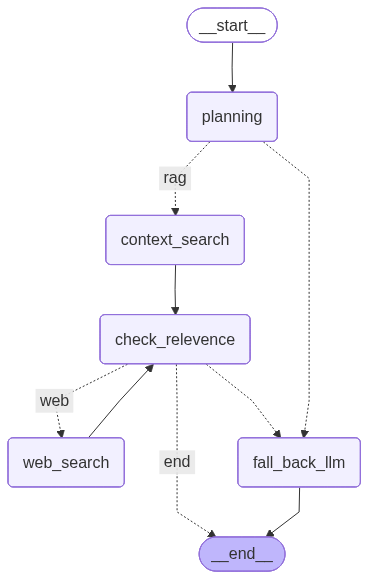

In [88]:
checkpointer = InMemorySaver()
chatbot = graph.compile(checkpointer=checkpointer)
chatbot

# Question to agent

web search

In [89]:
config = {"configurable": {"thread_id": "thread-1"}}

In [90]:
initial_state = {
    'question': "Who is the current Prime Minister of Pakistan?"
}

res = chatbot.invoke(initial_state, config=config)
res

Planning node started
Who is the current Prime Minister of Pakistan?
Classification: non_greeting
Memory classification: general_knowledge
CONTEXT FROM LONG TERM MEMORY
Relevant information from previous conversations:
- User's name is Syed Najiullah
- User has a best friend named Idrees
- User has another best friend named Ammar Noor

Planning node finised
context search started
CONTEXT: question_answer: Question: What is (are) Marshall-Smith syndrome ?. Answer: Marshall-Smith syndrome is a malformation syndrome characterized by advanced bone age, failure to thrive, respiratory problems, dysmorphic facial features, and variable mental retardation. Less than 40 cases have been reported in the literature, mostly as single case reports or small series. Early death is common due to respiratory complications. The cause of this disease remains unknown, but its sporadic occurrence suggests a de novo (new) dominant mutation. Aggressive management of the early respiratory and feeding problems 

{'question': 'Who is the current Prime Minister of Pakistan?',
 'messages': [SystemMessage(content='\n      You are an Agentic RAG assistant.\n\n      You MUST follow these rules exactly:\n\n         1. If the question is of greeting category then just go to the fallback LLM node to formally reply.\n         2. If the question can be asnwered from long term memory then use fall back llm node to formally reply.\n         3. Use vector surch node for each and every question.\n         4. If the question is not found in the vector store, use web search node.\n         5. If the question is not found in the web search, use fall back llm node.\n\n      ', additional_kwargs={}, response_metadata={}, id='10481ab0-387b-4d82-9682-d6fbe73cdb2a'),
  HumanMessage(content='Who is the current Prime Minister of Pakistan?', additional_kwargs={}, response_metadata={}, id='1d728540-0198-444b-a0dd-ff8830ed81a4'),
  AIMessage(content='Syed Najiullah, the current Prime Minister of Pakistan is Mian Muhammad

In [91]:
ai_msg = res["messages"][-1].content
print(ai_msg)

Syed Najiullah, the current Prime Minister of Pakistan is Mian Muhammad Shehbaz Sharif, who took office on 4 March 2024.


fallback node search

In [92]:
initial_state = {
    'question': "Hello, How are you?"
}

res = chatbot.invoke(initial_state, config=config)
res

Planning node started
Hello, how are you?
Classification: greeting
Memory classification: general_knowledge
CONTEXT FROM LONG TERM MEMORY
Relevant information from previous conversations:
- User's name is Syed Najiullah
- User has a best friend named Idrees
- User has another best friend named Ammar Noor
- User loves making projects on LangGraph, LangChain, Qdrant, Mem0, and PostgreSQL
- User loves playing chess
- User loves playing cricket and football
- User does not like playing snooker because it is a rich man's game

Planning node finised
fallback node started
fall back node finished


{'question': 'Hello, how are you?',
 'messages': [SystemMessage(content='\n      You are an Agentic RAG assistant.\n\n      You MUST follow these rules exactly:\n\n         1. If the question is of greeting category then just go to the fallback LLM node to formally reply.\n         2. If the question can be asnwered from long term memory then use fall back llm node to formally reply.\n         3. Use vector surch node for each and every question.\n         4. If the question is not found in the vector store, use web search node.\n         5. If the question is not found in the web search, use fall back llm node.\n\n      ', additional_kwargs={}, response_metadata={}, id='10481ab0-387b-4d82-9682-d6fbe73cdb2a'),
  HumanMessage(content='Who is the current Prime Minister of Pakistan?', additional_kwargs={}, response_metadata={}, id='1d728540-0198-444b-a0dd-ff8830ed81a4'),
  AIMessage(content='Syed Najiullah, the current Prime Minister of Pakistan is Mian Muhammad Shehbaz Sharif, who took o

In [93]:
ai_msg = res["messages"][-1].content
print(ai_msg)

Hello Syed Najiullah, I am operating well—thank you for asking.


In [94]:
initial_state = {
    'question': "Tell me information about who iam and my friends."
}

res = chatbot.invoke(initial_state, config=config)
res

Planning node started


Tell me information about who I am and my friends.
Classification: non_greeting
Memory classification: self_memory
CONTEXT FROM LONG TERM MEMORY
Relevant information from previous conversations:
- User loves making projects on LangGraph, LangChain, Qdrant, Mem0, and PostgreSQL
- User loves playing cricket and football
- User is building an agentic RAG application using LangChain, LangGraph, FastAPI, Mem0, Qdrant, and PostgreSQL.
- User has a best friend named Idrees
- User's name is Syed Najiullah
- User has another best friend named Ammar Noor
- User loves playing chess
- User does not like playing snooker because it is a rich man's game

Planning node finised
fallback node started
fall back node finished


{'question': 'Tell me information about who I am and my friends.',
 'messages': [SystemMessage(content='\n      You are an Agentic RAG assistant.\n\n      You MUST follow these rules exactly:\n\n         1. If the question is of greeting category then just go to the fallback LLM node to formally reply.\n         2. If the question can be asnwered from long term memory then use fall back llm node to formally reply.\n         3. Use vector surch node for each and every question.\n         4. If the question is not found in the vector store, use web search node.\n         5. If the question is not found in the web search, use fall back llm node.\n\n      ', additional_kwargs={}, response_metadata={}, id='10481ab0-387b-4d82-9682-d6fbe73cdb2a'),
  HumanMessage(content='Who is the current Prime Minister of Pakistan?', additional_kwargs={}, response_metadata={}, id='1d728540-0198-444b-a0dd-ff8830ed81a4'),
  AIMessage(content='Syed Najiullah, the current Prime Minister of Pakistan is Mian Muha

In [95]:
ai_msg = res["messages"][-1].content
print(ai_msg)

Syed Najiullah, my records show you are an enthusiast of LangGraph, LangChain, Qdrant, Mem0 and PostgreSQL who is currently crafting an agentic RAG application with those tools.  
Outside of work you enjoy cricket, football and chess, while you avoid snooker because you consider it “a rich man’s game.”  
Your closest friends are Idrees and Ammar Noor.


In [108]:
initial_state = {
    'question': "and how is it different from long term memory?"
}

res = chatbot.invoke(initial_state, config=config)
res

Planning node started
And how is it different from long-term memory?
Classification: non_greeting
Memory classification: general_knowledge
CONTEXT FROM LONG TERM MEMORY
Relevant information from previous conversations:
- User does not like playing snooker because it is a rich man's game
- User loves making projects on LangGraph, LangChain, Qdrant, Mem0, and PostgreSQL
- User is building an agentic RAG application using LangChain, LangGraph, FastAPI, Mem0, Qdrant, and PostgreSQL.
- User's name is Syed Najiullah
- User has a best friend named Idrees
- User has another best friend named Ammar Noor
- User loves playing chess

Planning node finised
context search started
CONTEXT: question_answer: Question: What is (are) Memory ?. Answer: Your mind works a lot like a computer. Your brain puts information it judges to be important into "files." When you remember something, you pull up a file. Memory doesn't always work perfectly. As people grow older, it may take longer to retrieve those file

{'question': 'And how is it different from long-term memory?',
 'messages': [SystemMessage(content='\n      You are an Agentic RAG assistant.\n\n      You MUST follow these rules exactly:\n\n         1. If the question is of greeting category then just go to the fallback LLM node to formally reply.\n         2. If the question can be asnwered from long term memory then use fall back llm node to formally reply.\n         3. Use vector surch node for each and every question.\n         4. If the question is not found in the vector store, use web search node.\n         5. If the question is not found in the web search, use fall back llm node.\n\n      ', additional_kwargs={}, response_metadata={}, id='10481ab0-387b-4d82-9682-d6fbe73cdb2a'),
  HumanMessage(content='Who is the current Prime Minister of Pakistan?', additional_kwargs={}, response_metadata={}, id='1d728540-0198-444b-a0dd-ff8830ed81a4'),
  AIMessage(content='Syed Najiullah, the current Prime Minister of Pakistan is Mian Muhammad

In [109]:
ai_msg = res["messages"][-1].content
print(ai_msg)

Syed Najiullah, short-term memory differs from long-term memory in three key ways:

1. Duration: short-term traces last only 15-30 seconds, whereas long-term memories can persist for weeks, months or years.
2. Capacity: short-term memory has a small, fixed “chunk” limit, while long-term storage is effectively unlimited.
3. Stability: short-term memories are still “live” and being validated; once transferred, long-term memories become fixed and fully assimilated.


rag search

In [98]:
initial_state = {
    'question': "Who is at risk for Lymphocytic Choriomeningitis (LCM)?"
}

res = chatbot.invoke(initial_state, config=config)
res

Planning node started
Who is at risk for lymphocytic choriomeningitis (LCM)?
Classification: non_greeting
Memory classification: general_knowledge
CONTEXT FROM LONG TERM MEMORY
Relevant information from previous conversations:
- User loves playing chess
- User loves making projects on LangGraph, LangChain, Qdrant, Mem0, and PostgreSQL

Planning node finised
context search started
CONTEXT: question_answer: Question: Who is at risk for Lymphocytic Choriomeningitis (LCM)? ?. Answer: Individuals of all ages who come into contact with urine, feces, saliva, or blood of wild mice are potentially at risk for infection. Owners of pet mice or hamsters may be at risk for infection if these animals originate from colonies that were contaminated with LCMV, or if their animals are infected from other wild mice. Human fetuses are at risk of acquiring infection vertically from an infected mother. 
                
Laboratory workers who work with the virus or handle infected animals are also at risk. 

{'question': 'Who is at risk for lymphocytic choriomeningitis (LCM)?',
 'messages': [SystemMessage(content='\n      You are an Agentic RAG assistant.\n\n      You MUST follow these rules exactly:\n\n         1. If the question is of greeting category then just go to the fallback LLM node to formally reply.\n         2. If the question can be asnwered from long term memory then use fall back llm node to formally reply.\n         3. Use vector surch node for each and every question.\n         4. If the question is not found in the vector store, use web search node.\n         5. If the question is not found in the web search, use fall back llm node.\n\n      ', additional_kwargs={}, response_metadata={}, id='10481ab0-387b-4d82-9682-d6fbe73cdb2a'),
  HumanMessage(content='Who is the current Prime Minister of Pakistan?', additional_kwargs={}, response_metadata={}, id='1d728540-0198-444b-a0dd-ff8830ed81a4'),
  AIMessage(content='Syed Najiullah, the current Prime Minister of Pakistan is Mian 

In [99]:
ai_msg = res["messages"][-1].content
print(ai_msg)

People at risk for lymphocytic choriomeningitis (LCM) include:

- Anyone who handles or is exposed to fresh urine, droppings, saliva, nesting material, blood, or bite wounds from infected wild or pet rodents (especially mice and hamsters)
- Pet owners whose rodents come from contaminated colonies or have contact with wild mice
- Laboratory workers who work with LCMV or infected animals (risk is reduced with proper screening, PPE, and safety protocols)
- Human fetuses, who can acquire the virus vertically from an infected mother
